In [1]:
import os
import glob
import json
import yaml
import numpy as np
import torch
import argparse

import sys
from pathlib import Path
__abs_path__ = str(Path.cwd().parents[0].absolute())
__utils_path__ = f'{__abs_path__}/utils'

for __util_path__ in [__abs_path__, __utils_path__]:
    if not __util_path__ in sys.path:
        sys.path+=[__util_path__]
        
from evaluation import Options, Trainer
import pickle
import trimesh
from utils.arg_util import YamlArgParser
from utils.remesh_utils import ICT_face_model
from utils.matplotlib_rnd import (
    render_mesh_diff,
    plot_image_array
)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
config = f'{__abs_path__}/config/train.yml'
opts_yaml = yaml.load(open(config), Loader=yaml.FullLoader)
opts = argparse.Namespace(**opts_yaml)

opts.ckpt = '../ckpt_stage1/2024-08-18-23-32-29-all' ## 20 ------> load checkpoint
# opts.ckpt = '../ckpt_stage1/2025-04-12-08-30-12-all' ## 20
# opts.ckpt = '../ckpt_stage1/2024-07-08-06-27-12-all' ## 20
# opts.ckpt = '../ckpt_stage1/2024-06-09-10-57-34-all' ## 20
# opts.ckpt = '../ckpt_stage1/exp_019_ICT_MF-jacob_NFR'
opts.ckpt = '../ckpts_nfs/nfs_ckpt'
opts.NFR = False

if opts.NFR:
    opts.design = 'nfr'
    opts.dec_type = 'jacob'
else:
    opts.design = 'new2'
    opts.dec_type = 'disp'


opts.device="cuda:0"

opts.data_rand_trans=False
opts.data_rand_scale=False
opts.learn_rig_emb=False
opts.use_decimate = False
opts.stage1 = True
opts.scale_exp = 1.0

trainer = Trainer(opts)
print('done')

FileNotFoundError: [Errno 2] No such file or directory: '/source/sihun/NeuralFacialAnimation/config/train.yml'

# Retarget single frame

(11248, 3)


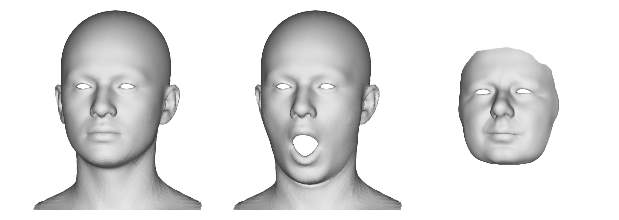

In [4]:
## full head
ict_face_model = ICT_face_model()
ict_tri = ict_face_model.get_mesh()

## flame
flame_tri = trimesh.load(f'{__abs_path__}/test-mesh/flame_final_transformed.obj', process=False, maintain_order=True)

BIWI_SELECT_MESH=0
# BIWI_SELECT_MESH=12
biwi_trimesh = trimesh.load(f'{__abs_path__}/test-mesh/BIWI.ply')
with open(f'{__abs_path__}/test-mesh/biwi_templates.pkl', 'rb') as f:
    mesh = pickle.load(f)
mesh_list = [idname for idname in mesh.keys() if idname!='face']
mesh_v = mesh[mesh_list[BIWI_SELECT_MESH]]
m_align = np.load(f'{__abs_path__}/utils/biwi/align.npy')
mesh_v = np.concatenate((mesh_v,np.ones((mesh_v.shape[0],1))), axis=1) @ m_align.T
biwi_trimesh.vertices=mesh_v

## ICT random expression
bs_coeff = np.eye(53)[26]
vertices = torch.from_numpy(ict_tri.vertices + ict_face_model.get_exp_disp(bs_coeff))
src_mesh = ict_tri

#tgt_mesh = flame_tri
tgt_mesh = biwi_trimesh


print(ict_tri.vertices.shape)

M_SCALE = 0.68
v_list=[ src_mesh.vertices, vertices[0], tgt_mesh.vertices ]
f_list=[ src_mesh.faces, src_mesh.faces, tgt_mesh.faces ]
SIZE=2
v_list=[v * M_SCALE for v in v_list]

plot_image_array(
    v_list, f_list,
    rot_list=[[0,-10,0]]*len(v_list), 
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"_tmp/train", 
    name=f"test", save=False
)

In [5]:
pred_outputs = trainer.model.inference(
#     gt_vertices=
    vertices,
    src_mesh=src_mesh, 
    tgt_mesh=tgt_mesh
)

100%|██████████| 1/1 [00:00<00:00, 10.88it/s]


 source neutral 	|	 source expression 	|	 target neutral 	|	 target expression


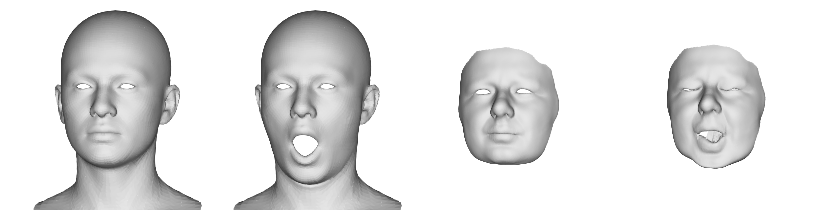

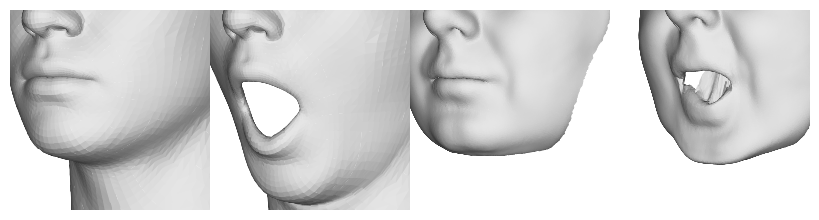

In [7]:
v_list=[src_mesh.vertices, vertices[0], tgt_mesh.vertices, pred_outputs.detach().cpu().numpy()[0] ]
f_list=[src_mesh.faces, src_mesh.faces, tgt_mesh.faces, tgt_mesh.faces ]

v_list1=[v * M_SCALE for v in v_list]
print(' source neutral \t|\t source expression \t|\t target neutral \t|\t target expression')
plot_image_array(
    v_list1, f_list,
    rot_list=[[0,-10,0]]*len(v_list), 
    size=SIZE, bg_black=False, mode='shade', 
)
M_SCALE_zoom=1.7
v_list2=[v * M_SCALE_zoom + np.array([0,0.9,0]) for v in v_list]
plot_image_array(
    v_list2, f_list,
    rot_list=[[0,-35,0]]*len(v_list), 
    size=SIZE, bg_black=False, mode='shade', 
)

# Retarget Animation

In [5]:
from dataloader_CBD import (
    EvalDataset,
    CBDDataBatch_eval,
    CBD_collate_wrapper_eval,
)
from functools import partial
from tqdm import tqdm
from glob import glob
import igl
import trimesh
import pickle

from utils import nfr_utils
import ipywidgets as widgets
import matplotlib.pyplot as plt

try:
    from matplotrender import *
except:
    !pip install git+https://github.com/chacorp/matplotrender.git
    from matplotrender import *

In [6]:
def get_mesh(selection, dataset, SELECT_MESH):
    if selection=='ict'or selection=='ict-cap':
        # id_vecs = np.load(f'{__abs_path__}/data/ICT_live_100/iden_vecs.npy')
        # id_vecs = np.load(f'{__abs_path__}/ict_face_pt/random_identity_vecs.npy')[:101]
        id_vecs = torch.load(f'{__abs_path__}/ict_face_pt/ict_id_vecs_test.pt').numpy()
        id_disps = dataset.ict_face_model.get_id_disp(id_vecs[SELECT_MESH])
        mesh_v = dataset.ict_face_model.neutral_verts.squeeze() + id_disps.squeeze()
        
        return mesh_v, dataset.ict_face_model.faces
    else:
        if selection=='voca':
            mesh = dataset.voca_mesh
        elif selection=='biwi':
            # mesh = dataset.biwi_mesh            
            biwi_trimesh = trimesh.load(f'{__abs_path__}/test-mesh/BIWI.ply')
            with open(f'{__abs_path__}/test-mesh/biwi_templates.pkl', 'rb') as f:
                mesh = pickle.load(f)
                
            mesh['face']=biwi_trimesh.faces
        elif selection=='mf_SEN':
            mesh = dataset.mf_SEN_mesh
        elif selection=='coma':
            mesh = dataset.coma_mesh
        elif selection=='mf_ROM':
            mesh = dataset.mf_ROM_mesh

        mesh_list = [idname for idname in mesh.keys() if idname!='face']
        mesh_v = mesh[mesh_list[SELECT_MESH]]

        if selection=='biwi':
            m_align = np.load(f'{__abs_path__}/utils/biwi/align.npy')
            mesh_v = np.concatenate((mesh_v,np.ones((mesh_v.shape[0],1))), axis=1) @ m_align.T
        return mesh_v, mesh['face']

In [7]:
device='cuda:0'
SRC_SELECT_DATA=4
SRC_SELECT_MESH=12
EXP_NUM=0


BS=1
data_name_list = ['voca','biwi','mf_SEN','coma','mf_ROM','ict','ict-cap'] # 0 1 2 3 4 5 6
src_selection = data_name_list[SRC_SELECT_DATA]

src_dataset = EvalDataset(
    data_name=src_selection, 
    toggle=False, 
    ict_cap_id_num  = SRC_SELECT_MESH,
    ict_cap_exp_num = EXP_NUM,
) # if eve-s01

src_dataloader = torch.utils.data.DataLoader(
    src_dataset,
    batch_size=BS,
    collate_fn=partial(CBD_collate_wrapper_eval, device=device),
)
len_data = len(src_dataset)
len_dataloader = len(src_dataloader)
print(f'max data length: {len_data}')
print(f'max dataloader: {len_dataloader}')

src_v, src_f = get_mesh(src_selection, src_dataset, SRC_SELECT_MESH)
src_n = igl.per_vertex_normals(src_v, src_f)

mf ROM data list exists: /source/sihun/NeuralFacialAnimation/utils/data/mf_ROM_vertex_data_test.txt
max data length: 11649
max dataloader: 11649


In [8]:
TGT_SELECT_DATA=4
TGT_SELECT_mesh=12

# ict test id [2 4 5 6 10 11 12] (at NFS)
# ict test id [0 5 6]
data_name_list = ['voca','biwi','mf_SEN','coma','mf_ROM','ict','ict-cap']
tgt_selection = data_name_list[TGT_SELECT_DATA]

tgt_dataset = EvalDataset(data_name=tgt_selection, toggle=False, ict_cap_id_num=TGT_SELECT_mesh) # if eve-s01

tgt_v, tgt_f = get_mesh(tgt_selection, tgt_dataset, TGT_SELECT_mesh)

tgt_n = igl.per_vertex_normals(tgt_v, tgt_f)
tgt_v_th = torch.tensor(tgt_v).float()[None].to(device)
tgt_n_th = torch.tensor(tgt_n).float()[None].to(device)

mf ROM data list exists: /source/sihun/NeuralFacialAnimation/utils/data/mf_ROM_vertex_data_test.txt


(5223, 3) (5223, 3)


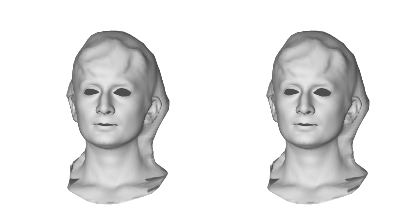

In [9]:
print(src_v.shape, tgt_v.shape)

M_SCALE = 0.5
v_list=[ src_v, tgt_v ]
f_list=[ src_f, tgt_f ]
SIZE=2
rot_list=[[0,-10,0]]

plot_mesh_gouraud(v_list, f_list, mesh_scale=M_SCALE,
        rot_list=rot_list*len(v_list), size=SIZE, mode='shade', bg_black=False)

In [10]:
# file_name = 'coma-to-mf_ROM'
# file_name = 'mf_ROM_test-to-mf_ROM_val'
# file_name = 'mf_ROM_test-to-mf_ROM_test'
# file_name = 'mf_SEN_test-to-mf_SEN_test'
if src_selection == 'ict-cap':
    file_name = f'{src_selection}-ID_{SRC_SELECT_MESH:03d}_test-to-{tgt_selection}-ID_{TGT_SELECT_mesh:03d}_test_{EXP_NUM:02d}'
else:
    if 'ict' in  tgt_selection:
        file_name = f'{src_selection}_test-to-{tgt_selection}_test-ID_{TGT_SELECT_mesh:03d}'
    else:
        file_name = f'{src_selection}_test-to-{tgt_selection}_test'
        # file_name = f'{src_selection}_test-to-{tgt_selection}_test'
        # file_name = f'{src_selection}_test-to-{tgt_selection}_val'
        # file_name = f'{src_selection}_test-to-{tgt_selection}_train'
a2b_retarget_path = __abs_path__ + '/eval_CBD/'+opts.ckpt.split('/')[-1]+'/'+file_name
print(a2b_retarget_path)
os.makedirs(a2b_retarget_path, exist_ok=True) 

/source/sihun/NeuralFacialAnimation/eval_CBD/2024-08-18-23-32-29-all/mf_ROM_test-to-mf_ROM_test


In [37]:
tgt_m = trimesh.Trimesh(vertices=tgt_v, faces=tgt_f)
tgt_dfn_info = nfr_utils.get_dfn_info(tgt_m, map_location=device)
tgt_verts = tgt_v_th[0]
tgt_faces = torch.from_numpy(tgt_m.faces).to(device)
tgt_img = trainer.model.renderer.render_img(tgt_m).float().to(device)
tgt_img_feat = trainer.model.get_img_feat(tgt_img)
tgt_vert_feat = trainer.model.get_local_feature(tgt_verts[None], tgt_faces, tgt_img_feat).float()
# tgt_operators = trainer.model.get_mesh_operators(tgt_m)
pred_id_coeff  = trainer.model.encode_id(tgt_vert_feat, tgt_dfn_info)
pred_seg_coeff = trainer.model.encode_seg(tgt_vert_feat, tgt_dfn_info)

pbar = tqdm(enumerate(src_dataloader), total=len_dataloader, ncols=100)
for index, batch in pbar:
    if index == 0:
        if index==0:
            src_m = trimesh.Trimesh(vertices=batch.template[0].cpu().numpy(), faces=batch.faces[0].cpu().numpy())
            src_dfn_info = nfr_utils.get_dfn_info(src_m, map_location=device)
            img = trainer.model.renderer.render_img(src_m).float().to(device)
            img_feat = trainer.model.get_img_feat(img)
        else:
            if (batch.template[0].cpu().numpy() - src_m.vertices).mean() != 0:
                src_m = trimesh.Trimesh(vertices=batch.template[0].cpu().numpy(), faces=batch.faces[0].cpu().numpy())
                src_dfn_info = nfr_utils.get_dfn_info(src_m, map_location=device)
                img = trainer.model.renderer.render_img(src_m).float().to(device)
                img_feat = trainer.model.get_img_feat(img)
                
        with torch.no_grad():
            vert_feat_exp = []
            for b_idx in range(BS):
                if b_idx < batch.vertices.shape[0]:
                    src_v_th = batch.vertices[b_idx]
                    _tmp_ = trainer.model.get_local_feature(src_v_th[None], batch.faces[0], img_feat).float()
                    vert_feat_exp.append(_tmp_)
            vert_feat_exp = torch.vstack(vert_feat_exp)
            # vert_feat_exp = trainer.model.get_local_feature(batch.vertices, batch.faces[0], img_feat).float()
            pred_exp_coeff = trainer.model.encode_exp(vert_feat_exp, src_dfn_info, batch_process=True, verbose=False)# [W, Rig]
            
            inputs = (
                tgt_vert_feat, pred_exp_coeff, pred_id_coeff, pred_seg_coeff,
                None, tgt_verts[None], tgt_faces, None
            )
            pred_vertices, _ = trainer.model.decode(inputs, batch_process=True)
            
        pred_output_np = pred_vertices.detach().cpu().numpy()
        for b_idx in range(BS):
            if b_idx < batch.vertices.shape[0]:
                np.save(a2b_retarget_path+f'/{index*BS+b_idx:05d}', pred_output_np[b_idx])
        break

  0%|                                                                     | 0/11649 [00:03<?, ?it/s]


     source neutral 	|	 source expression 	|	 target neutral 	|	 target expression


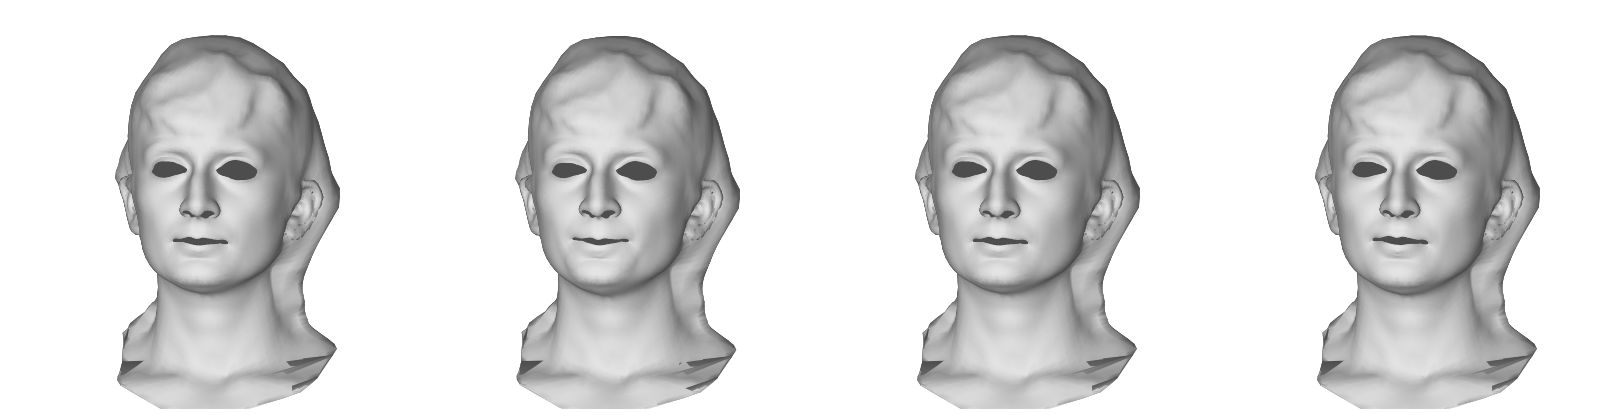

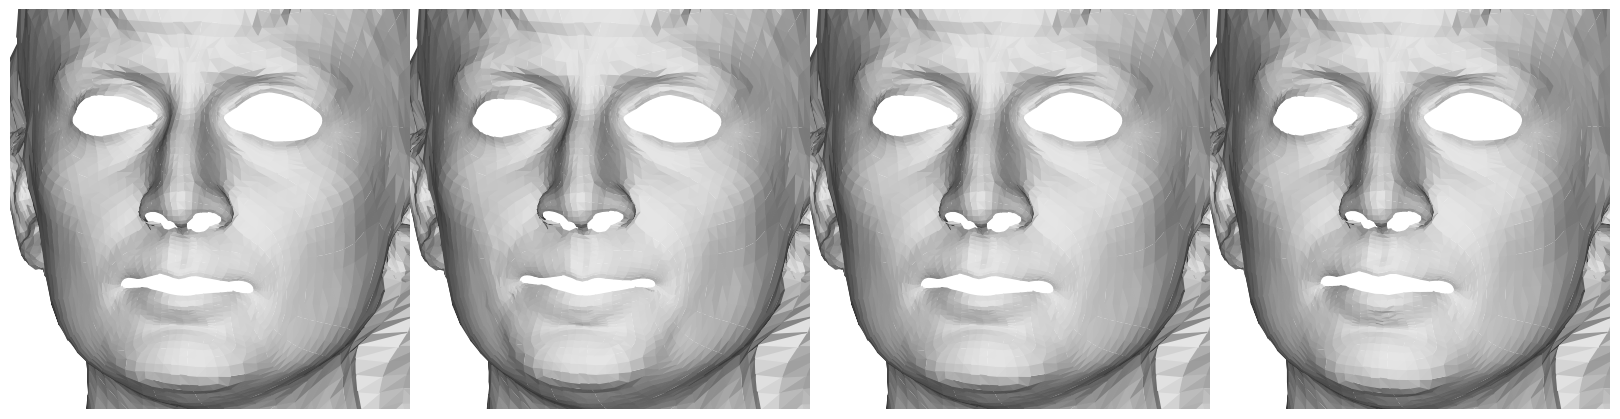

In [38]:
SIZE=6
M_SCALE=.55
M_SCALE_zoom=1.3
SAVE=0

FRAME = 0

M_trns=np.array([0,0.,0])
v_list=[
    batch.template.detach().cpu().numpy()[FRAME],
    batch.vertices.detach().cpu().numpy()[FRAME],
    tgt_v,
    pred_output_np[FRAME],
]
# v_list = [v * M_SCALE + M_trns for v in v_list]
f_list=[ src_f, src_f, tgt_f, tgt_f]

print('     source neutral \t|\t source expression \t|\t target neutral \t|\t target expression')
plot_mesh_gouraud(
    v_list, f_list, mesh_scale=M_SCALE, mesh_trans=M_trns,
    rot_list=rot_list*len(v_list), size=4,
    mode='shade', bg_black=False
)
v_list = [v * M_SCALE_zoom + M_trns for v in v_list]
plot_image_array(
    v_list, f_list,
    rot_list=rot_list*len(v_list), size=4,
    mode='shade', bg_black=False
)

In [55]:
torch.cuda.empty_cache()
print(a2b_retarget_path)

/source/sihun/NeuralFacialAnimation/eval_CBD/2024-07-08-06-27-12-all/mf_ROM_test-to-mf_ROM_test


In [74]:
print(a2b_retarget_path)
SELF_RETARGET= SRC_SELECT_MESH==TGT_SELECT_mesh

if SELF_RETARGET:
    print('self-retargeting!')
    
    pbar = tqdm(enumerate(src_dataloader), total=len_dataloader, ncols=100)
    for index, batch in pbar:
        if index==0:
            src_verts = batch.template[0].cpu().numpy()
            src_faces = batch.faces[0].cpu().numpy()
            src_m = trimesh.Trimesh(vertices=src_verts, faces=src_faces)
            src_dfn_info = nfr_utils.get_dfn_info(src_m, map_location=device)
            src_img = trainer.model.renderer.render_img(src_m).float().to(device)
            src_img_feat = trainer.model.get_img_feat(src_img)
            src_vert_feat = trainer.model.get_local_feature(batch.template[0][None], batch.faces[0], src_img_feat).float()
            
            pred_seg_coeff = trainer.model.encode_seg(src_vert_feat, src_dfn_info)# [1, V, Seg]
            pred_id_coeff  = trainer.model.encode_id(src_vert_feat, src_dfn_info)
        else:
            if (batch.template[0].cpu().numpy() - src_m.vertices).mean() != 0:
                src_verts = batch.template[0].cpu().numpy()
                src_faces = batch.faces[0].cpu().numpy()
                src_m = trimesh.Trimesh(vertices=src_verts, faces=src_faces)
                src_dfn_info = nfr_utils.get_dfn_info(src_m, map_location=device)
                src_img = trainer.model.renderer.render_img(src_m).float().to(device)
                src_img_feat = trainer.model.get_img_feat(src_img)
                src_vert_feat = trainer.model.get_local_feature(batch.template[0][None], batch.faces[0], src_img_feat).float()
                
                pred_seg_coeff = trainer.model.encode_seg(src_vert_feat, src_dfn_info)# [1, V, Seg]
                pred_id_coeff  = trainer.model.encode_id(src_vert_feat, src_dfn_info)
                
        with torch.no_grad():
            vert_feat_exp = []
            for b_v in batch.vertices:
                _tmp_ = trainer.model.get_local_feature(b_v[None], batch.faces[0], src_img_feat).float()
                vert_feat_exp.append(_tmp_)
            vert_feat_exp = torch.vstack(vert_feat_exp)
            pred_exp_coeff = trainer.model.encode_exp(vert_feat_exp, src_dfn_info, batch_process=True, verbose=False)# [W, Rig]
            
            # pred_exp_coeff = trainer.model.apply_gaussian_filter(
            #     pred_exp_coeff.squeeze(1), kernel_size=3, sigma=1.0
            # )
            
            inputs = (
                src_vert_feat, pred_exp_coeff, pred_id_coeff, pred_seg_coeff,
                None, batch.template[0][None], batch.faces[0], None
            )
            pred_vertices, _ = trainer.model.decode(inputs, batch_process=True)
            
            pred_output_np = pred_vertices.detach().cpu().numpy()
            for b_idx in range(BS):
                if b_idx < batch.vertices.shape[0]:
                    np.save(a2b_retarget_path+f'/{index*BS+b_idx:05d}', pred_output_np[b_idx])
else:
    print('cross-retargeting!')
    tgt_m = trimesh.Trimesh(vertices=tgt_v, faces=tgt_f)
    tgt_dfn_info = nfr_utils.get_dfn_info(tgt_m, map_location=device)
    tgt_verts = tgt_v_th[0]
    tgt_faces = torch.from_numpy(tgt_m.faces).to(device)
    tgt_img = trainer.model.renderer.render_img(tgt_m).float().to(device)
    tgt_img_feat = trainer.model.get_img_feat(tgt_img)
    tgt_vert_feat = trainer.model.get_local_feature(tgt_verts[None], tgt_faces, tgt_img_feat).float()
    
    with torch.no_grad():
        pred_seg_coeff = trainer.model.encode_seg(tgt_vert_feat, tgt_dfn_info)# [1, V, Seg]
        pred_id_coeff  = trainer.model.encode_id(tgt_vert_feat, tgt_dfn_info)
    
    pbar = tqdm(enumerate(src_dataloader), total=len_dataloader, ncols=100)
    for index, batch in pbar:
        if index==0:
            src_m = trimesh.Trimesh(vertices=batch.template[0].cpu().numpy(), faces=batch.faces[0].cpu().numpy())
            src_dfn_info = nfr_utils.get_dfn_info(src_m, map_location=device)
            src_img = trainer.model.renderer.render_img(src_m).float().to(device)
            src_img_feat = trainer.model.get_img_feat(src_img)
        else:
            if (batch.template[0].cpu().numpy() - src_m.vertices).mean() != 0:
                src_m = trimesh.Trimesh(vertices=batch.template[0].cpu().numpy(), faces=batch.faces[0].cpu().numpy())
                src_dfn_info = nfr_utils.get_dfn_info(src_m, map_location=device)
                src_img = trainer.model.renderer.render_img(src_m).float().to(device)
                src_img_feat = trainer.model.get_img_feat(src_img)
                
        with torch.no_grad():
            vert_feat_exp = []
            for b_v in batch.vertices:
                _tmp_ = trainer.model.get_local_feature(b_v[None], batch.faces[0], src_img_feat).float()
                vert_feat_exp.append(_tmp_)
            vert_feat_exp = torch.vstack(vert_feat_exp)
            pred_exp_coeff = trainer.model.encode_exp(vert_feat_exp, src_dfn_info, batch_process=True, verbose=False)# [W, Rig]
            
            inputs = (
                tgt_vert_feat, pred_exp_coeff, pred_id_coeff, pred_seg_coeff,
                None, tgt_verts[None], tgt_faces, None
            )
            pred_vertices, _ = trainer.model.decode(inputs, batch_process=True)
            
            pred_output_np = pred_vertices.detach().cpu().numpy()
            for b_idx in range(BS):
                if b_idx < batch.vertices.shape[0]:
                    np.save(a2b_retarget_path+f'/{index*BS+b_idx:05d}', pred_output_np[b_idx])

# NFR
### ICT self-retargeting    204/204 [19:43<00:00,  5.80s/it] 3260/3260 [30:37<00:00,  1.77it/s] 
### MF_rom self-retargeting 729/729 [02:56<00:00,  4.13it/s]

/source/sihun/NeuralFacialAnimation/eval_CBD/2024-08-18-23-32-29-all/mf_ROM_test-to-mf_ROM_test
self-retargeting!


100%|█████████████████████████████████████████████████████████| 11649/11649 [03:30<00:00, 55.46it/s]


In [11]:
print(a2b_retarget_path)
mesh_file_paths = sorted(glob(a2b_retarget_path+'/*.npy'))
len_mesh_file_paths=len(mesh_file_paths)
print(len(mesh_file_paths))

GT_a2b_retarget_path = '/source/sihun/NeuralFacialAnimation/eval_CBD/GT-mf_ROM_test-to-mf_ROM_test'
print(GT_a2b_retarget_path)
GT_mesh_file_paths = sorted(glob(GT_a2b_retarget_path+'/*.npy'))
GT_len_mesh_file_paths=len(GT_mesh_file_paths)
print(len(GT_mesh_file_paths))

/source/sihun/NeuralFacialAnimation/eval_CBD/2024-08-18-23-32-29-all/mf_ROM_test-to-mf_ROM_test
11649
/source/sihun/NeuralFacialAnimation/eval_CBD/GT-mf_ROM_test-to-mf_ROM_test
11649


In [12]:
# MSE: 5.63616e-04 fir
# MSE: 5.12866e-04
## 5.11772e-04 2024-07-08-06-27-12-all
## 5.51832e-04 2024-08-18

# __mse__ = 0
__mse__ = []
criterion = torch.nn.MSELoss()
for gt, pred in zip(GT_mesh_file_paths, mesh_file_paths):
    pred = torch.from_numpy(np.load(pred))
    gt = torch.from_numpy(np.load(gt))
    # __mse__ += np.power(gt - pred, 2).mean()
    # __mse__.append(np.power((gt - pred).mean(), 2)) ##E5
    __mse__.append(criterion(gt, pred))
    # __mse__ += criterion(gt, pred)
# __mse__ = __mse__ / len(GT_mesh_file_paths)
__mse__ = np.array(__mse__)
__mse___mu = np.mean(__mse__)
__mse___std = np.std(__mse__)

# print(f"MSE: {__mse__:.5e}")
print(f"MSE: {__mse___mu:.5e}")
print(f"STD: {__mse___std:.5e}")

MSE: 5.51832e-04
STD: 5.93720e-04


In [68]:
(gt - pred).mean().pow(2)

tensor(3.9949e-06)

     source neutral 	|	 source expression 	|	 target neutral 	|	 target expression


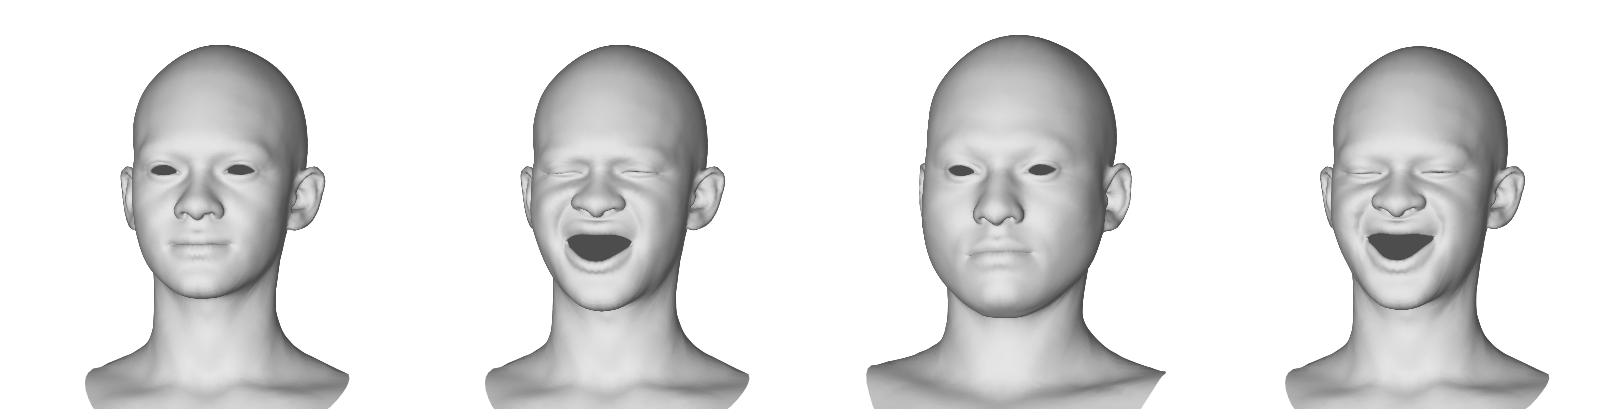

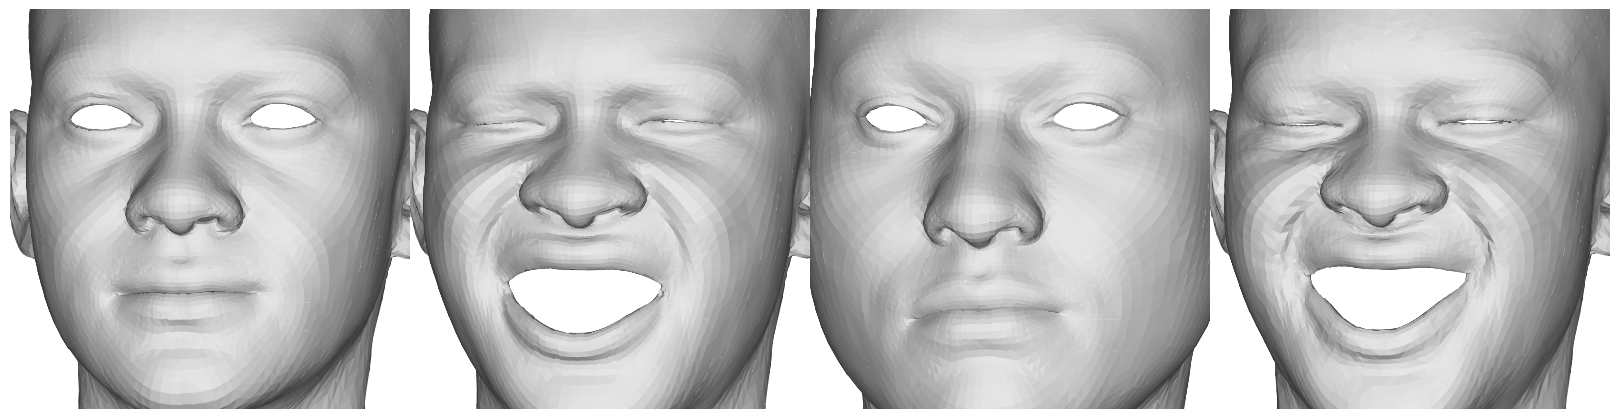

In [13]:
SIZE=6
M_SCALE=.55
M_SCALE_zoom=1.3
SAVE=0

FRAME = 1

M_trns=np.array([0,0.,0])
v_list=[
    batch.template.detach().cpu().numpy()[FRAME],
    batch.vertices.detach().cpu().numpy()[FRAME],
    tgt_v,
    # batch.template.detach().cpu().numpy()[FRAME],
    pred_output_np[FRAME],
]
# v_list = [v * M_SCALE + M_trns for v in v_list]
f_list=[ src_f, src_f, tgt_f, tgt_f]

print('     source neutral \t|\t source expression \t|\t target neutral \t|\t target expression')
plot_mesh_gouraud(
    v_list, f_list, mesh_scale=M_SCALE, mesh_trans=M_trns,
    rot_list=rot_list*len(v_list), size=4,
    mode='shade', bg_black=False
)
v_list = [v * M_SCALE_zoom + M_trns for v in v_list]
plot_image_array(
    v_list, f_list,
    rot_list=rot_list*len(v_list), size=4,
    mode='shade', bg_black=False
)

In [28]:
print(a2b_retarget_path)
mesh_file_paths = sorted(glob(a2b_retarget_path+'/*.npy'))
len_mesh_file_paths=len(mesh_file_paths)
print(len(mesh_file_paths))


# GT_file_name = 'GT-'+file_name
# GT_file_name = f'GT-{src_selection}_test-to-{src_selection}_test'
GT_file_name = f'GT-{src_selection}_test-to-{src_selection}_test_{EXP_NUM:02d}'
# GT_file_name = 'GT-mf_ROM_test-to-mf_ROM_test'
GT_a2b_retarget_path = __abs_path__ + '/eval_CBD/'+ GT_file_name

print(GT_a2b_retarget_path)
GT_mesh_file_paths = sorted(glob(GT_a2b_retarget_path+'/*.npy'))
GT_len_mesh_file_paths=len(GT_mesh_file_paths)
print(len(GT_mesh_file_paths))

/source/sihun/NeuralFacialAnimation/eval_CBD/2024-08-18-23-32-29-all/mf_ROM_test-to-mf_ROM_test
11649
/source/sihun/NeuralFacialAnimation/eval_CBD/GT-mf_ROM_test-to-mf_ROM_test_00
11649


In [15]:
mesh_file_paths[10]

'/source/sihun/NeuralFacialAnimation/eval_CBD/nfs/ict_test-to-ict_test/00010.npy'

In [17]:
vvv= np.load(mesh_file_paths[0]).squeeze()
np.r_[vvv[None],vvv[None],vvv[None]].shape

(3, 5223, 3)

In [26]:
SAVE=0
rot_list=[[0,-10,0]]
M_SCALE=0.6
M_SCALE=1.

def update_frame(frame):
    plt.close()
    
    vvv= np.load(mesh_file_paths[frame]).squeeze()
    if frame >0 and frame < 11648:
        vvv_pv= np.load(mesh_file_paths[frame-1]).squeeze()
        vvv_nx= np.load(mesh_file_paths[frame+1]).squeeze()
        vvv_t = np.r_[vvv_pv[None],vvv[None],vvv_nx[None]]
        vvv_t = torch.from_numpy(vvv_t).float().to(trainer.model.device)
        # print(vvv_t.shape) # (3, 5223, 3)
        vvv_t = trainer.model.apply_gaussian_filter(
            vvv_t.reshape(3, -1), kernel_size=3, sigma=.8
        ).reshape(3, 5223, 3).detach().cpu().numpy()
        vvv = vvv_t[1]
    vvvGT= np.load(GT_mesh_file_paths[frame]).squeeze()
    
    v_list = [vvvGT, vvv]
    f_list = [src_f, tgt_f]
    
    # plot_mesh_gouraud(
    #     v_list, f_list, mesh_scale=M_SCALE,
    #     rot_list=rot_list*len(v_list), size=4, mode='shade', bg_black=False
    # )
    
    v_list = [v * M_SCALE for v in v_list]
    plot_image_array(
        v_list, f_list,
        rot_list=rot_list*len(v_list), size=4, mode='shade', bg_black=False
    )

slider = widgets.IntSlider(value=0, min=0, max=len_mesh_file_paths-1, step=1, description='Frame:')

widgets.interactive(update_frame, frame=slider)
# widgets.interact(update_frame, frame=slider)

interactive(children=(IntSlider(value=0, description='Frame:', max=11648), Output()), _dom_classes=('widget-in…

# Load

In [22]:
data_name_list = ['voca','biwi','mf_SEN','coma','mf_ROM','ict'] # 0 1 2 3 4 5
SRC_SELECT_DATA=2
TGT_SELECT_DATA=2

SRC_SELECT_MESH=-1
TGT_SELECT_mesh=-1

src_selection = data_name_list[SRC_SELECT_DATA]
tgt_selection = data_name_list[TGT_SELECT_DATA]


file_name = f'{src_selection}_test-to-{tgt_selection}_test'

a2b_retarget_path = __abs_path__ + '/eval_CBD/nfs/'+file_name
print(a2b_retarget_path)
nfs_mesh_file_paths = sorted(glob(a2b_retarget_path+'/*.npy'))
len_nfr_mesh_file_paths=len(nfs_mesh_file_paths)
print(len(nfs_mesh_file_paths))

GT_a2b_retarget_path = __abs_path__ + '/eval_CBD/GT-'+file_name
print(GT_a2b_retarget_path)
GT_mesh_file_paths = sorted(glob(GT_a2b_retarget_path+'/*.npy'))
GT_len_mesh_file_paths=len(GT_mesh_file_paths)
print(len(GT_mesh_file_paths))

/source/sihun/NeuralFacialAnimation/eval_CBD/nfs/mf_SEN_test-to-mf_SEN_test
6309
/source/sihun/NeuralFacialAnimation/eval_CBD/GT-mf_SEN_test-to-mf_SEN_test
6309


In [23]:
__mse__ = 0
for gt, pred in zip(GT_mesh_file_paths, nfs_mesh_file_paths):
    pred = np.load(pred)
    gt = np.load(gt)
    __mse__ += np.power(gt - pred, 2).mean()
__mse__ = __mse__ / len(GT_mesh_file_paths)
print(f"MSE: {__mse__:.5e}")

MSE: 4.95892e-04
